# Module 2 — Regression for Driver Analysis

## Why you're here: what the model is for
- A credit-card company in Taiwan has 30,000 card holders. Next month, the bank
  will mark some of them as having **defaulted**: not paying what they owe.
  Defaulted debt is money the company may never get back.
- The risk team wants to know **what goes together with defaulting**: how late
  the client paid recently, how big their bill is, their credit limit, their age.
  Ranking those characteristics, and measuring each one's link to default, is
  called **driver analysis**.
- The column we predict is **`default`**: 1 = the bank recorded the client as
  defaulting in October, 0 = it didn't. **The dataset never defines exactly what
  counts as default** (missing the minimum payment? the full bill? being late by
  some amount?), so every result here describes "what the bank labelled default".
- The tool is **regression**, which puts a number on each characteristic's link
  to the target, and says how sure we can be of that number.

**Your endgame in this module:** read a regression's output and turn it into
honest driver statements: which characteristics matter, by how much, how
certain we are, and why "goes together with" is not the same as "causes".

## From the curriculum

> ### <u>Module 2 — Regression for Driver Analysis</u>
>
> **Concepts**
> - Linear regression (continuous target) and logistic regression (binary target)
>   in scikit-learn, and reading their coefficients (for logistic: log-odds and
>   odds ratios)
> - scikit-learn is built for prediction: its `LogisticRegression` reports no
>   p-values or confidence intervals (CIs), and by default applies a penalty that
>   pulls coefficients toward zero (negligible with large samples, noticeable with
>   small ones). statsmodels is built for inference: unpenalized estimates with
>   p-values and CIs
> - Standardized coefficients, to compare drivers measured in different units
> - Multicollinearity (the six monthly repayment-status columns move together)
>   and VIF (Variance Inflation Factor)
> - A driver is an association inside this data, not a cause
>
> **Why it matters**
> "What drives default / churn / conversion?" is the most common modelling
> question an analyst gets. Answering it with shrunken coefficients, or reading a
> coefficient as a causal effect, is a common and costly mistake.
>
> **Worked example**
> Logistic regression of next-month default on repayment history, credit limit,
> bill and payment amounts, and personal attributes: the same model fitted in
> scikit-learn (for prediction) and in statsmodels (for inference). With 18,000
> training rows the two agree almost exactly; on a 300-row sample, the default
> penalty visibly shrinks scikit-learn's coefficients. Odds ratios then translate
> the key driver into a plain-English sentence.
>
> **Resources**
> - [Regression and Other Stories](https://avehtari.github.io/ROS-Examples/)
>   (Gelman, Hill & Vehtari, 2020; free PDF linked from the book's homepage,
>   verified). Ch. 10 "Linear regression with multiple predictors" and Ch. 13
>   "Logistic regression", ~45 min each, optional.
>
> **Exercise type:** interpret-the-output drills: turn a statsmodels summary into
> driver statements, each tagged Observation/Hypothesis/Conclusion, with the
> causal caveat stated.
>
> **Interview angle:** "How would you find what drives churn?" / "How do you
> interpret a logistic regression coefficient?"

## Lesson

### What regression does
1. **A formula with one number per column.** Regression fits a formula of the form
   *prediction = intercept + b₁ × column₁ + b₂ × column₂ + …*. Each **b** is a
   **coefficient**, and the **intercept** is the prediction when every column is 0.
2. **What a coefficient means.** *b₁* is how much the prediction changes when
   column₁ goes up by 1, **with every other column held fixed**. That last part is
   the point of regression. Age and credit limit tend to rise together, for
   example, and regression separates their links to the target instead of
   crediting one with the other's.
3. **Training** (fitting) means choosing the *b*'s that make the formula's
   predictions match the known answers in the training rows as closely as possible.

### Two kinds of regression
- **Linear regression**: the target is a **number**, like a credit limit. Each
  coefficient is in the target's own units: "+1 year of age → +2,180 NT$ (New Taiwan dollars) of limit".
- **Logistic regression**: the target is **yes/no**, like default. A straight-line
  formula could predict −20% or 130%, so logistic regression predicts something
  that has no floor or ceiling, the **log-odds**, and converts it back to a
  probability. The next section builds that up from scratch.

### Probability, odds and log-odds
- **Probability**: the share of cases where it happens. A default probability of
  0.20 means 20 in 100 clients default.
- **Odds**: how many cases happen for each case that doesn't. *odds = p / (1 − p)*.
  For p = 0.20: odds = 0.20 / 0.80 = 0.25, i.e. **1 default for every 4 clients who pay**.
- **Log-odds**: the natural logarithm of the odds. It can be any number, negative
  or positive, which is why the formula can predict it freely.

Logistic regression's formula is *log-odds = intercept + b₁ × column₁ + …*. So when
column₁ goes up by 1, the log-odds go up by *b₁*, which means the odds get
**multiplied by e^b₁**. That multiplier is the **odds ratio**. Because e raised to
any power is positive, an odds ratio is always above 0:
- b₁ > 0 → odds ratio **above 1**: the column goes together with **more** default;
- b₁ < 0 → odds ratio **between 0 and 1**: with **less** default;
- b₁ = 0 → odds ratio **exactly 1**: no link.

**Odds are not probability.** Doubling the odds doesn't double the probability.
Starting from a 14% probability, odds = 0.14 / 0.86 = 0.163. Doubled, that's 0.326,
which converts back to a probability of 0.326 / 1.326 = 24.6%, not 28%.

### How sure are we: p-values and confidence intervals
The same two tools as in the A/B Testing Playbook, now attached to each coefficient:
- the **confidence interval (CI)** of an odds ratio is the range of odds ratios
  consistent with the data. A 95% CI that excludes 1 means the link is
  statistically distinguishable from "no link";
- the **p-value** tests "this column has no link to the target, once the others
  are held fixed" (odds ratio = 1).

### Two libraries, two jobs
- **scikit-learn** is built for **prediction**: it fits the formula and scores new
  rows, but reports **no p-values and no confidence intervals**. By default its
  logistic regression also applies a **penalty**: a nudge that pulls every
  coefficient slightly toward 0, to guard against over-fitting small samples.
- **statsmodels** is built for **inference**, meaning drawing conclusions about the
  coefficients themselves. It fits without a penalty and reports p-values and CIs.

### When columns move together: multicollinearity
If two columns carry almost the same information (this month's bill and last
month's bill, say), regression can't tell which one deserves the credit. Their
coefficients become unstable, meaning they can swing, even flip sign, with small
changes in the data, and their CIs become wide. This is **multicollinearity**.
The **VIF** (Variance Inflation Factor) measures it per column: how many times
larger that coefficient's uncertainty is because of its overlap with the other
columns. VIF = 1 means no overlap. A common rule of thumb treats values above
5–10 as a problem.

### A driver is not a cause
Despite how it sounds, **"driver" is industry shorthand for a factor that goes
together with the outcome**, strongly and consistently. It does not mean the
factor causes the outcome.

Every result in this module is an **association** inside this data: clients with
X default more often, with the other columns held fixed. It is *not* evidence
that changing X would change default. Many unmeasured things (income, job
security, other debts) sit behind the columns we do have.

### Part 0 — The data, its quality issues, and the locked split
**Default of Credit Card Clients** (UCI, CC BY 4.0; Yeh & Lien, 2009).
- **One row = one card holder** at a Taiwanese bank, 2005.
- **30,000 rows**, a single snapshot: every client is observed over the same six
  months (April to September 2005), then the target records October.
- **Target `default`**: 1 if the bank recorded the client as defaulting the
  following month (22.1% of rows), 0 if not. What counts as default isn't defined
  (first quality issue below).

| Column(s) | Meaning |
|---|---|
| `LIMIT_BAL` | credit limit, in NT$ (New Taiwan dollars) |
| `SEX` | 1 = male, 2 = female |
| `EDUCATION` | 1 = graduate school, 2 = university, 3 = high school; others undocumented |
| `MARRIAGE` | 1 = married, 2 = single, 3 = other; 0 undocumented |
| `AGE` | age in years |
| `PAY_1`…`PAY_6` | repayment status, September back to April: 1–9 = months late (September's is misnamed `PAY_0` in the original file; renamed here) |
| `BILL_AMT1`…`BILL_AMT6` | bill amount, September back to April, NT$ |
| `PAY_AMT1`…`PAY_AMT6` | amount paid, September back to April, NT$ |
| `default` | **target**: recorded by the bank as defaulting in October? (definition not given) |

Below: the first two rows, plus client 3319, who is examined month by month right after.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from common import load_credit, credit_split

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

df = load_credit()
print(f"Rows: {len(df):,}   Missing cells: {df.isna().sum().sum()}")
print(f"Defaulted (default = 1): {df['default'].sum():,} of {len(df):,} = {df['default'].mean():.1%}")
df.loc[[1, 2, 3319]]

Rows: 30,000   Missing cells: 0
Defaulted (default = 1): 6,636 of 30,000 = 22.1%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3319,200000,1,2,1,36,2,-1,-1,-1,-2,...,2200,0,0,3238,2655,0,0,0,1966,1


**How a row is laid out.** Each row is one client, with six monthly columns of
each kind (April to September) side by side. **`default` is recorded once, for
October only.** For April to September, the data records how late the client was,
not whether they defaulted. Client 3319, the last row of the table above,
rearranged month by month:

In [2]:
client = df.loc[3319]
months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
rows = {
    "months late (PAY_)":   [f"{client[c]:d}" for c in ["PAY_6", "PAY_5", "PAY_4", "PAY_3", "PAY_2", "PAY_1"]] + [""],
    "bill, NT$ (BILL_AMT)": [f"{client[f'BILL_AMT{i}']:,}" for i in range(6, 0, -1)] + [""],
    "paid, NT$ (PAY_AMT)":  [f"{client[f'PAY_AMT{i}']:,}" for i in range(6, 0, -1)] + [""],
    "default":              [""] * 6 + [f"{client['default']:d}"],
}
layout = pd.DataFrame(rows, index=months + ["Oct"]).T
print(f"Client {client.name}: credit limit {client['LIMIT_BAL']:,} NT$, age {client['AGE']}")
print(layout.to_string())

Client 3319: credit limit 200,000 NT$, age 36
                        Apr May    Jun    Jul    Aug    Sep Oct
months late (PAY_)       -2  -2     -1     -1     -1      2    
bill, NT$ (BILL_AMT)      0   0  2,200  2,655  3,238  7,300    
paid, NT$ (PAY_AMT)   1,966   0      0      0  2,655  3,238    
default                                                       1


Reading it, codes against amounts:
- **April–May:** no bill, status −2 (not defined by the documentation).
- **June–August:** status −1, which the documentation defines as "paid duly".
  But the amounts disagree. In August and September, each payment matches the
  *previous* month's bill exactly (August's 2,655 = July's bill; September's
  3,238 = August's), yet **June's bill of 2,200 is never paid**, and July's payment
  is 0.
- **September:** 2 months late, and the bill more than doubles, to 7,300.
- **October:** the bank recorded a default.

So for this client, **the status codes and the amounts don't agree**. The codes
say June to August were on time (the dataset's source defines −1 as "pay duly");
the amounts show June's bill left unpaid.

**Data-quality checks.** The next cell looks, across all 30,000 clients, for
values the documentation doesn't explain: codes outside the documented list in
`EDUCATION` (documented: 1–3), `MARRIAGE` (1–3) and the repayment status
(−1 and 1–9), negative bills, and duplicate rows. Anything it finds has to be
handled before modelling, because a model treats an unexplained code as if it
were meaningful.

In [3]:
# Data-quality checks
documented = {"EDUCATION": {1, 2, 3}, "MARRIAGE": {1, 2, 3},
              "PAY_1": {-1, *range(1, 10)}, "PAY_2": {-1, *range(1, 10)}}
for col, known in documented.items():
    counts = df[col].value_counts().sort_index()
    unknown = [c for c in counts.index if c not in known]
    print(f"{col + ' codes:':<16} {counts.to_dict()}")
    print(f"  undocumented: {', '.join(str(c) for c in unknown)} ({counts[unknown].sum():,} clients)")
m0 = df["MARRIAGE"] == 0
print(f"MARRIAGE = 0: {m0.sum()} clients, {df.loc[m0, 'default'].mean():.1%} defaulted; "
      f"all 'not married' (codes 0, 2, 3): {(df['MARRIAGE'] != 1).sum():,} clients")
print(f"Rows with a negative bill in any month: {(df.filter(like='BILL_AMT') < 0).any(axis=1).sum():,}")
print(f"Rows identical to another row (ignoring ID): {df.duplicated().sum()}")
print()
print("Default rate by the three non-positive PAY_1 codes (-1 documented, -2 and 0 not):")
for code_ in [-2, -1, 0]:
    grp = df.loc[df["PAY_1"] == code_, "default"]
    print(f"  PAY_1 = {code_:>2}: {len(grp):,} clients, {grp.mean():.1%} defaulted")

EDUCATION codes: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
  undocumented: 0, 4, 5, 6 (468 clients)
MARRIAGE codes:  {0: 54, 1: 13659, 2: 15964, 3: 323}
  undocumented: 0 (54 clients)
PAY_1 codes:     {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
  undocumented: -2, 0 (17,496 clients)
PAY_2 codes:     {-2: 3782, -1: 6050, 0: 15730, 1: 28, 2: 3927, 3: 326, 4: 99, 5: 25, 6: 12, 7: 20, 8: 1}
  undocumented: -2, 0 (19,512 clients)
MARRIAGE = 0: 54 clients, 9.3% defaulted; all 'not married' (codes 0, 2, 3): 16,341 clients
Rows with a negative bill in any month: 1,930
Rows identical to another row (ignoring ID): 35

Default rate by the three non-positive PAY_1 codes (-1 documented, -2 and 0 not):
  PAY_1 = -2: 2,759 clients, 13.2% defaulted
  PAY_1 = -1: 5,686 clients, 16.8% defaulted
  PAY_1 =  0: 14,737 clients, 12.8% defaulted


**Observation:** seven quality issues, each with the decision taken:
- **The target is not defined.** The documentation says only "default payment
  (yes/no)", not whether it means missing the minimum payment, the full bill, or
  a lateness threshold. Every result describes "what the bank labelled default in
  October". The link between being late (the `PAY_` columns) and defaulting is
  plausible but unspecified: the two may partly be the same event, recorded two
  ways.
- **Undocumented `EDUCATION` codes** 0, 4, 5 and 6 (468 clients). We group them as
  "other education" and watch them closely in Part 4.
- **Undocumented `MARRIAGE` code** 0 (54 clients, 9.3% defaulted, unusually low
  like the undocumented education codes). Too few for a group of their own, so
  they count as "not married"; at 54 of 16,341, they can't shift that group's
  estimate noticeably. Education's undocumented codes (468 clients) are enough to
  isolate, so they get their own group.
- **A misnamed column.** In the original file, September's repayment status is
  called `PAY_0`, and there is no `PAY_1`, while bills and payments number
  September as 1 (`BILL_AMT1`, `PAY_AMT1`). It's a naming error in the file, so
  `common.py` renames it **`PAY_1`** on loading, and everything below uses that name.
- **Undocumented repayment codes** −2 and 0: the source defines only −1 ("pay
  duly", i.e. on time) and 1–9 (months late), yet 0 is the most common value. The
  three non-positive codes (−2, −1, 0) have similar default rates (12.8% to
  16.8%), so we treat all of them as **0 months late**.
- **The code 1 ("one month late") almost never appears** in `PAY_2` (28 clients)
  but is common in `PAY_1` (3,688), so the months seem to have been coded
  differently.
- **1,930 clients have a negative bill** in at least one month (plausibly a
  credit balance after an overpayment), and 35 rows duplicate another row. Both
  are kept: neither is clearly an error.

**A choice, not a data rule:** only September's and August's lateness are used.
For driver analysis, one column per idea would suggest `late_sep` alone, or a
total across months; keeping two was a judgment call. (August shares the
earlier months' coding quirk.) Part 5 tests the alternatives.

**Other limits:** a single snapshot of one bank in 2005, during a period of
heavy card debt in Taiwan, so results describe this population, not card holders
in general. `SEX`, `AGE` and `MARRIAGE` are **protected attributes**: we measure
their association with default here, and Module 6 decides whether they may be
used in a score.

**The locked split.** From this module on, the credit data is split **once**,
with a fixed seed (in `common.py`), into three parts:
1. **Test (20%): not used at all until Module 6.** There, **only the winning
   model** is graded on these rows, once.
2. **Validation (20%):** every model is compared on these rows, along the way.
   They're also needed in Module 5, where the reason is explained.
3. **Training (60%):** models learn from these rows.

The driver analysis below is fitted on the training rows only.

In [4]:
train, valid, test = credit_split(df)
for name, part in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:<10}: {len(part):,} rows, {part['default'].mean():.2%} defaulted")

def driver_columns(d):
    """The columns used for driver analysis, prepared as decided above. Amounts in thousands of NT$."""
    edu = d["EDUCATION"].map({1: "graduate", 2: "university", 3: "high school"}).fillna("other")
    return pd.DataFrame({
        "limit_k":        d["LIMIT_BAL"] / 1000,
        "age":            d["AGE"],
        "female":         (d["SEX"] == 2).astype(int),
        "married":        (d["MARRIAGE"] == 1).astype(int),
        "edu_graduate":   (edu == "graduate").astype(int),      # compared with university
        "edu_highschool": (edu == "high school").astype(int),
        "edu_other":      (edu == "other").astype(int),
        "late_sep":       d["PAY_1"].clip(lower=0),              # months late in September
        "late_aug":       d["PAY_2"].clip(lower=0),              # months late in August
        "bill_sep_k":     d["BILL_AMT1"] / 1000,
        "paid_sep_k":     d["PAY_AMT1"] / 1000,
    }, index=d.index)

X_train, y_train = driver_columns(train), train["default"]
X_valid, y_valid = driver_columns(valid), valid["default"]
print("\nThe same three clients as the raw sample above (1, 2 and 3319), now with the prepared columns:")
print(X_train.loc[[1, 2, 3319]].to_string())

train     : 18,000 rows, 22.12% defaulted
validation: 6,000 rows, 22.12% defaulted
test      : 6,000 rows, 22.12% defaulted

The same three clients as the raw sample above (1, 2 and 3319), now with the prepared columns:
      limit_k  age  female  married  edu_graduate  edu_highschool  edu_other  late_sep  late_aug  bill_sep_k  paid_sep_k
ID                                                                                                                      
1        20.0   24       1        1             0               0          0         2         2       3.913       0.000
2       120.0   26       1        0             0               0          0         0         2       2.682       0.000
3319    200.0   36       0        1             0               0          0         2         0       7.300       3.238


**The prepared columns.** The models below use these names, built from the raw
columns as follows:

| Name in the tables | Built from | Meaning |
|---|---|---|
| `limit_k` | `LIMIT_BAL` ÷ 1,000 | credit limit, thousands of NT$ |
| `age` | `AGE` | age in years |
| `female` | `SEX` = 2 | 1 = female, 0 = male |
| `married` | `MARRIAGE` = 1 | 1 = married, 0 = not |
| `edu_graduate`, `edu_highschool`, `edu_other` | `EDUCATION` | 1 = in that education group; each compared with university |
| `late_sep` | `PAY_1`, negatives set to 0 | months late in September (0–8) |
| `late_aug` | `PAY_2`, negatives set to 0 | months late in August (0–8) |
| `bill_sep_k` | `BILL_AMT1` ÷ 1,000 | September bill, thousands of NT$ |
| `paid_sep_k` | `PAY_AMT1` ÷ 1,000 | amount paid in September, thousands of NT$ |

Education is split into three 0/1 columns (graduate, high school, other). The
fourth group, **university**, has no column: it's the **reference group** that the
other three are compared against. Leaving one group out is required, because
the four columns would otherwise always add up to 1 and duplicate the intercept.

### Part 1 — Linear regression: what goes together with a client's credit limit?
A warm-up with a **number** as the target. The bank set each client's credit limit
*before* the six months of behaviour in the data, so only the personal-attribute
columns can sensibly go with it.

In [5]:
demo = ["age", "female", "married", "edu_graduate", "edu_highschool", "edu_other"]
limit_k = train["LIMIT_BAL"] / 1000

sk_linear = LinearRegression().fit(X_train[demo], limit_k)
sm_linear = sm.OLS(limit_k, sm.add_constant(X_train[demo])).fit()

table = pd.DataFrame({
    "coefficient":              sm_linear.params[demo].values,
    "95% CI low (statsmodels)":  sm_linear.conf_int().loc[demo, 0].values,
    "95% CI high (statsmodels)": sm_linear.conf_int().loc[demo, 1].values,
    "p-value (statsmodels)":     sm_linear.pvalues[demo].values,
}, index=demo).round(2)
table["p-value (statsmodels)"] = [f"{p:.3f}" if p >= 0.001 else "<0.001" for p in sm_linear.pvalues[demo]]
print("Coefficients, in thousands of NT$ of credit limit:")
print(table.to_string())
gap = np.abs(sk_linear.coef_ - sm_linear.params[demo].values).max()
print(f"\nscikit-learn's coefficients vs statsmodels': largest difference = {gap:.10f} (identical)")
print(f"\nIntercept: {sm_linear.params['const']:.1f}   R-squared: {sm_linear.rsquared:.3f}")

Coefficients, in thousands of NT$ of credit limit:
                coefficient  95% CI low (statsmodels)  95% CI high (statsmodels) p-value (statsmodels)
age                    2.18                      1.96                       2.40                <0.001
female                13.06                      9.39                      16.73                <0.001
married               22.85                     18.80                      26.90                <0.001
edu_graduate          70.97                     66.95                      74.99                <0.001
edu_highschool       -35.38                    -40.61                     -30.14                <0.001
edu_other             32.10                     17.72                      46.49                <0.001

scikit-learn's coefficients vs statsmodels': largest difference = 0.0000000000 (identical)

Intercept: 51.4   R-squared: 0.115


**Reading it:**
- **One coefficient column, because both libraries give the same numbers.**
  They solve the same problem (make the squared prediction errors as small as
  possible, with no penalty), so the answer is identical by construction; the
  last line checks it. Only statsmodels adds the CIs and p-values.
- **Each coefficient, in plain words** (other columns held fixed):
  - age: +2.18k NT$ of limit per extra year of age;
  - female: +13.06k NT$ compared with male;
  - married: +22.85k NT$ compared with not married;
  - graduate school: +70.97k NT$ compared with university; high school: −35.38k NT$.
- **R-squared (R²) = 0.115**: the share of the differences in credit limit between
  clients that these columns account for. Here, 11.5%: these personal attributes explain
  little of how limits were set.

**Observation:** every p-value is below 0.001, yet together the columns explain
only 11.5% of credit limits. **Conclusion:** with 18,000 rows, even small links
come out statistically significant. *Significant* means "distinguishable from
zero", not "important". Always read the size of a coefficient and R² beside its
p-value.

**Hypothesis (not testable here):** the bank set limits mostly on information
not in this data (income, credit history elsewhere), which is why R² is low.

### Part 2 — Logistic regression: what goes together with default?
Before fitting any model, here's the raw data for the most promising column,
`late_sep` (months late in September, prepared from `PAY_1`): how often clients
defaulted, at each number of months late.

In [6]:
raw = train.assign(late_sep=X_train["late_sep"].clip(upper=4)).groupby("late_sep")["default"].agg(["size", "mean"])
raw.index = ["0", "1", "2", "3", "4+"]
raw.columns = ["clients", "default rate"]
print(raw.round(3).to_string())
print(f"\nAll clients: {len(train):,}, default rate {train['default'].mean():.3f}")

    clients  default rate
0     13932         0.140
1      2203         0.330
2      1601         0.693
3       187         0.781
4+       77         0.623

All clients: 18,000, default rate 0.221


**Observation:** 14.0% of clients who were on time in September defaulted in
October, against 33.0% of those one month late and 69.3% of those two months
late. Now the model, with every driver column in at once, so each one's link is
measured with the others held fixed:

In [7]:
logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
ci = np.exp(logit.conf_int())
drivers = pd.DataFrame({
    "coefficient": logit.params,
    "odds ratio":  np.exp(logit.params),
    "95% CI low":  ci[0],
    "95% CI high": ci[1],
    "p-value":     logit.pvalues,
}).drop(index="const").round(4)
drivers["p-value"] = [f"{p:.4f}" if p >= 0.001 else "<0.001" for p in logit.pvalues.drop("const")]
X_const = sm.add_constant(X_train)
drivers["VIF (1 = best; above 5–10 = problem)"] = [round(variance_inflation_factor(X_const.values, i), 2) for i in range(1, X_const.shape[1])]
print(drivers.to_string())

auc_part2 = roc_auc_score(y_valid, logit.predict(sm.add_constant(X_valid)))
print(f"\nValidation AUC of this model (graded on the validation rows): {auc_part2:.4f}")

                coefficient  odds ratio  95% CI low  95% CI high p-value  VIF (1 = best; above 5–10 = problem)
limit_k             -0.0018      0.9982      0.9978       0.9985  <0.001                                  1.31
age                  0.0044      1.0044      0.9996       1.0092  0.0712                                  1.35
female              -0.1610      0.8513      0.7863       0.9216  <0.001                                  1.02
married              0.1634      1.1776      1.0779       1.2864  <0.001                                  1.28
edu_graduate         0.0187      1.0189      0.9297       1.1165  0.6891                                  1.25
edu_highschool      -0.0322      0.9683      0.8666       1.0820  0.5698                                  1.20
edu_other           -1.5395      0.2145      0.1246       0.3692  <0.001                                  1.02
late_sep             0.9548      2.5982      2.4412       2.7654  <0.001                                  1.92
l

In [8]:
b = logit.params["late_sep"]
print(f"odds ratio for late_sep = e^b = e^{b:.4f} = {np.exp(b):.3f}")
p0 = 0.14
odds0 = p0 / (1 - p0)
odds1 = odds0 * np.exp(b)
print(f"worked example, starting at a {p0:.0%} default probability:")
print(f"  odds = {p0} / {1 - p0:.2f} = {odds0:.3f}")
print(f"  x {np.exp(b):.3f} for one extra month late = {odds1:.3f}")
print(f"  back to probability = {odds1:.3f} / (1 + {odds1:.3f}) = {odds1 / (1 + odds1):.1%}")
print(f"\nIn plain words: for a client with a {p0:.0%} default probability, being one extra month late "
      f"in September goes with a probability of about {odds1 / (1 + odds1):.1%}, roughly double.")

lim = train["LIMIT_BAL"]
print(f"\nCredit limit (NT$): lowest {lim.min():,}, middle half {lim.quantile(0.25):,.0f} to "
      f"{lim.quantile(0.75):,.0f}, highest {lim.max():,}")

odds ratio for late_sep = e^b = e^0.9548 = 2.598
worked example, starting at a 14% default probability:
  odds = 0.14 / 0.86 = 0.163
  x 2.598 for one extra month late = 0.423
  back to probability = 0.423 / (1 + 0.423) = 29.7%

In plain words: for a client with a 14% default probability, being one extra month late in September goes with a probability of about 29.7%, roughly double.

Credit limit (NT$): lowest 10,000, middle half 50,000 to 240,000, highest 800,000


**The drivers in plain words** (each with every other column held fixed):
- **Months late in September: odds ratio 2.60** (95% CI 2.44 to 2.77). Each extra
  month late multiplies the odds of default by 2.6. For a client at a 14%
  default probability, one extra month late moves them to about 29.7%. This is
  by far the strongest driver.
- **Months late in August: 1.22.** Smaller, but still clearly above 1.
- **Credit limit: 0.9982 per 1k NT$.** Tiny per thousand, but limits vary by
  hundreds of thousands (10,000 to 800,000 NT$, printed above). Part 3 compares drivers on a common scale.
- **Amount paid in September: 0.9875 per 1k NT$.** Paying more goes with less default.
- **Female: 0.85; married: 1.18.** Modest links, both clearly different from 1.
- **Age** (p = 0.07) and **bill amount** (p = 0.06): their CIs include 1, so the
  data can't distinguish their link from none. That's *not* evidence of "no link".
- **Other education: 0.21**, the largest effect in the table. Part 4 explains why
  it shouldn't be believed.

**Conclusion:** recent repayment behaviour dominates. **Correlation, not
causation:** being late doesn't *cause* default; both are most likely symptoms of
the same underlying money trouble, which the data doesn't measure.

**Where the formula's assumption breaks.** The model assumes each extra month late
multiplies the odds by the *same* 2.6, however late the client already is. Here
is its average prediction against the real default rate:

    clients  actual default rate  model's average prediction
0     13932                0.140                       0.141
1      2203                0.330                       0.362
2      1601                0.693                       0.615
3       187                0.781                       0.845
4+       77                0.623                       0.968


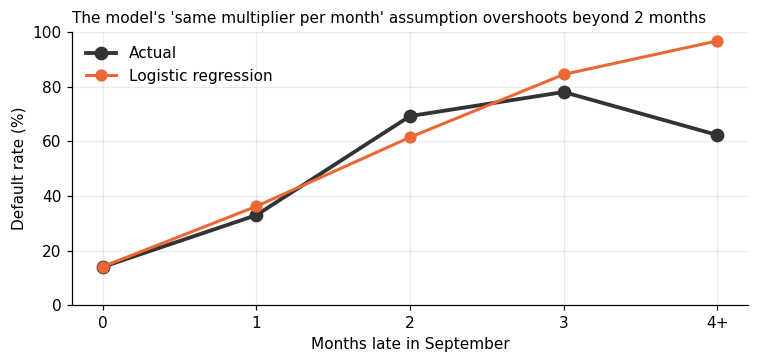

In [9]:
check = pd.DataFrame({
    "clients": raw["clients"].values,
    "actual default rate": raw["default rate"].values,
    "model's average prediction": logit.predict(sm.add_constant(X_train))
                                  .groupby(X_train["late_sep"].clip(upper=4)).mean().values,
}, index=raw.index)
print(check.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(check))
ax.plot(x, check["actual default rate"] * 100, marker="o", markersize=8, linewidth=2.5, color="#333333", label="Actual")
ax.plot(x, check["model's average prediction"] * 100, marker="o", markersize=7, linewidth=2, color=ORANGE, label="Logistic regression")
ax.set_xticks(x, check.index)
ax.set_xlabel("Months late in September")
ax.set_ylabel("Default rate (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="upper left")
ax.set_title("The model's 'same multiplier per month' assumption overshoots beyond 2 months", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** at 0 and 1 months late the model tracks reality closely. At 2
months it falls short (61.5% predicted against 69.3% actual), and beyond that it
overshoots: for 4+ months it predicts 96.8% against 62.3% actual, though that
group has only 77 clients. **Conclusion:** the odds ratio of 2.6 is a fair
summary for the first month late, and rough beyond it. It's not a law that holds
at any length. A tree model (Module 3) can capture a jump-then-flatten shape like
this without being told to.

### Part 3 — Comparing drivers fairly, and the two libraries side by side
Odds ratios per 1k NT$ and per month late can't be compared directly: the units
differ. To rank drivers, every column is first **standardized**: rescaled so that
1 unit = 1 standard deviation (STDEV: the typical spread of that column across
clients). A coefficient then reads "per typical difference between clients".
Only the continuous columns are rescaled; the 0/1 columns stay as they are, so
this is the same model as Part 2, just with some columns measured in different
units.

In [10]:
cont = ["limit_k", "age", "late_sep", "late_aug", "bill_sep_k", "paid_sep_k"]
scaler = StandardScaler().fit(X_train[cont])
Z_train = X_train.copy()
Z_train[cont] = scaler.transform(X_train[cont])

sm_std = sm.Logit(y_train, sm.add_constant(Z_train)).fit(disp=0)
sk_std = LogisticRegression(max_iter=5000).fit(Z_train, y_train)     # default penalty, C = 1.0

compare = pd.DataFrame({
    "1 STDEV =": [f"{s:,.3f}" for s in scaler.scale_],
    "statsmodels coef": sm_std.params[cont].values,
    "scikit-learn coef": pd.Series(sk_std.coef_[0], index=Z_train.columns)[cont].values,
    "odds ratio per 1 STDEV": np.exp(sm_std.params[cont].values),
}, index=cont).round(3)
orr = compare["odds ratio per 1 STDEV"]
compare["strength (sorted by this)"] = [f"x {o:.3f}" if o >= 1 else f"÷ {1 / o:.3f}  (= 1 / {o:.3f})" for o in orr]
compare = compare.iloc[np.argsort(-np.maximum(orr, 1 / orr).values)]
print(compare.to_string())
print("\nstrength = how far the odds ratio is from 1, in either direction: above 1 multiplies the odds (x),")
print("below 1 divides them (÷, shown as 1 / odds ratio so both directions are on the same scale)")
print(f"\nlargest gap between the two libraries: {np.abs(compare['statsmodels coef'] - compare['scikit-learn coef']).max():.3f}")
b_month = logit.params["late_sep"]
sd = scaler.scale_[cont.index("late_sep")]
print("\nSame model as Part 2? Checking late_sep side by side:")
print(f"  Part 2 (per 1 month late):  coefficient {b_month:.4f}, odds ratio {np.exp(b_month):.3f}")
print(f"  coefficient per 1 STDEV:     {b_month:.4f} x {sd:.3f} = {b_month * sd:.3f}   <- Part 3 table's statsmodels coef "
      f"({compare.loc['late_sep', 'statsmodels coef']:.3f}); 1 STDEV = {sd:.3f} months")
print(f"  odds ratio per 1 STDEV:      e^{b_month * sd:.3f} = {np.exp(b_month * sd):.3f}          <- Part 3 table's odds ratio per 1 STDEV "
      f"({compare.loc['late_sep', 'odds ratio per 1 STDEV']:.3f})")
print("  -> the two match: same model, only the unit changed")

           1 STDEV =  statsmodels coef  scikit-learn coef  odds ratio per 1 STDEV strength (sorted by this)
late_sep       0.752             0.718              0.716                   2.050                   x 2.050
limit_k      129.928            -0.239             -0.239                   0.787    ÷ 1.271  (= 1 / 0.787)
paid_sep_k    16.696            -0.210             -0.212                   0.810    ÷ 1.235  (= 1 / 0.810)
late_aug       0.798             0.160              0.161                   1.173                   x 1.173
bill_sep_k    73.273             0.043              0.043                   1.044                   x 1.044
age            9.252             0.041              0.040                   1.041                   x 1.041

strength = how far the odds ratio is from 1, in either direction: above 1 multiplies the odds (x),
below 1 divides them (÷, shown as 1 / odds ratio so both directions are on the same scale)

largest gap between the two libraries: 0.002

Same m

**Observation:** on a common scale, months late in September is the strongest
driver (odds × 2.05 per STDEV). Next come credit limit (÷ 1.27) and amount paid
in September (÷ 1.24), both meaning *more* goes with *less* default, then months
late in August (× 1.17). Age and bill amount barely register.

**The two libraries:** with 18,000 training rows, scikit-learn's default penalty
changes the coefficients by at most 0.002, which is nothing. Here's the same
comparison on small random samples of the training rows, where the penalty has
less data to be outweighed by. (The rare "other education" column is left out of
this comparison: a 300-row sample holds only a handful of its 287 clients, too
few for statsmodels to estimate it.)

In [11]:
rows = []
Z_small = Z_train.drop(columns="edu_other")
for n in [300, 1000, 18000]:
    sample = Z_small.sample(n, random_state=1) if n < len(Z_small) else Z_small
    ys = y_train.loc[sample.index]
    s_sm = sm.Logit(ys, sm.add_constant(sample)).fit(disp=0).params[cont].values
    s_sk = pd.Series(LogisticRegression(max_iter=5000).fit(sample, ys).coef_[0], index=sample.columns)[cont].values
    rows.append((n, s_sm[cont.index("late_sep")], s_sk[cont.index("late_sep")]))
pen = pd.DataFrame(rows, columns=["rows", "statsmodels", "scikit-learn"]).set_index("rows")
pen["shrinkage"] = 1 - pen["scikit-learn"] / pen["statsmodels"]
pen = pen.round(3) + 0.0      # + 0.0 turns a printed "-0.000" into "0.000"
print("Coefficient for late_sep (standardized), by sample size:")
print(pen.round(3).to_string())

Coefficient for late_sep (standardized), by sample size:
       statsmodels  scikit-learn  shrinkage
rows                                       
300          0.811         0.774      0.046
1000         0.785         0.778      0.010
18000        0.715         0.715      0.000


**Observation:** on 300 rows, scikit-learn's coefficient comes out a few percent
smaller than statsmodels'. On 18,000 rows the difference vanishes.
**Conclusion:** the penalty only matters with small samples, but scikit-learn
never gives p-values or CIs at all. So: **statsmodels for driver analysis,
scikit-learn for prediction pipelines** (Modules 3–6).

### Part 4 — Two traps: overlapping columns, and a "driver" made of bad codes
**Trap 1: multicollinearity.** Part 2's model uses one month each of bills and
payments. Here's what happens with all six months of both:

In [12]:
MONTH = {2: "aug", 3: "jul", 4: "jun", 5: "may", 6: "apr"}      # BILL_AMT2 = August ... BILL_AMT6 = April

def add_earlier_months(X, d):
    X = X.copy()
    for i, m in MONTH.items():
        X[f"bill_{m}_k"] = d[f"BILL_AMT{i}"] / 1000
        X[f"paid_{m}_k"] = d[f"PAY_AMT{i}"] / 1000
    return X

full = add_earlier_months(X_train, train)
full_const = sm.add_constant(full)
vif = pd.Series([variance_inflation_factor(full_const.values, i) for i in range(1, full_const.shape[1])],
                index=full.columns)
logit_full = sm.Logit(y_train, full_const).fit(disp=0)

bills = ["bill_sep_k"] + [f"bill_{m}_k" for m in MONTH.values()]
six = pd.DataFrame({"VIF (1 = best; above 5–10 = problem)": vif[bills], "coefficient": logit_full.params[bills],
                    "p-value": logit_full.pvalues[bills]}).round(4)
six["coefficient in Part 2's model"] = [f"{logit.params[c]:+.4f}" if c in logit.params else "(not in model)" for c in bills]
print("Six-month model (all six bills and payments):")
print(six.to_string())
print(f"\nFor comparison, Part 2's driver table (VIF column): highest {drivers['VIF (1 = best; above 5–10 = problem)'].max():.2f} ({drivers['VIF (1 = best; above 5–10 = problem)'].idxmax()})")

auc_six = roc_auc_score(y_valid, logit_full.predict(sm.add_constant(add_earlier_months(X_valid, valid))))
print(f"\nValidation AUC: six-month model {auc_six:.4f}; Part 2's model {auc_part2:.4f} (printed under Part 2's driver table)")

Six-month model (all six bills and payments):
            VIF (1 = best; above 5–10 = problem)  coefficient  p-value coefficient in Part 2's model
bill_sep_k                               13.7818      -0.0031   0.0263                       +0.0006
bill_aug_k                               26.8794       0.0034   0.0688                (not in model)
bill_jul_k                               23.4814       0.0003   0.8728                (not in model)
bill_jun_k                               22.0499      -0.0005   0.7619                (not in model)
bill_may_k                               27.0400      -0.0019   0.3603                (not in model)
bill_apr_k                               16.5323       0.0038   0.0310                (not in model)

For comparison, Part 2's driver table (VIF column): highest 1.95 (late_aug)

Validation AUC: six-month model 0.7487; Part 2's model 0.7447 (printed under Part 2's driver table)


**Observation:** the six monthly bills have VIFs of 13.8 to 27.0: each bill's
uncertainty is inflated more than tenfold by its overlap with the others. Their
coefficients flip sign from month to month (negative for September, positive for
August, and so on), and four of the six are indistinguishable from 0. September's
bill even changes sign between models: +0.0006 in Part 2's model, −0.0031
here. In Part 2's driver table, the highest VIF is 1.95 (`late_aug`).

**Conclusion:** two bill coefficients are statistically significant (September
p = 0.026, April p = 0.031), but they point in opposite directions, September's
flips sign between models, and both VIFs (13.8 and 16.5) are well above the
5–10 problem level from the Lesson. So even these can't be read as drivers. The
bills *together* carry information, but the regression can't split
it between months. For driver analysis, keep one column per idea. Validation
AUC (from Module 1: the chance a random defaulter is scored above a random
non-defaulter, measured on hidden rows) shows the cost: the six-month model
ranks clients slightly better, 0.7487 against 0.7447. That's the trade-off between a model you can
explain (Part 2's model) and one that squeezes out every bit of prediction
(the six-month model).

**Trap 2: the "other education" group.** Its odds ratio of 0.21 was the largest effect in Part 2. Here's who is in it:

In [13]:
edu_rates = train.groupby("EDUCATION")["default"].agg(["size", "mean"])
edu_rates.columns = ["clients", "default rate"]
edu_rates["documented?"] = edu_rates.index.map({1: "yes", 2: "yes", 3: "yes"}).fillna("NO")
print(edu_rates.round(3).to_string())

           clients  default rate documented?
EDUCATION                                   
0                8         0.000          NO
1             6409         0.193         yes
2             8309         0.236         yes
3             2995         0.257         yes
4               81         0.037          NO
5              173         0.058          NO
6               25         0.080          NO


**Observation:** the "other" group is made of the undocumented codes 0, 4, 5 and 6,
287 training clients whose default rate (0% to 8%) sits far below every
documented group (19% to 26%).

**Hypothesis:** these codes mark a data-collection quirk, for instance records
added or coded in a different way, rather than a real kind of education. That
would explain an implausibly low default rate. Confirming it would need the
bank's coding documentation.

**Conclusion:** don't report "other education" as a driver. A strong effect from
an undocumented category is a data question first. It stays in the model as its
own group, so it doesn't distort the documented groups, but it's excluded from
the driver statements.

### Part 5 — Does the lateness choice matter?
Part 0 called keeping two lateness months a judgment call. Here are the
alternatives, tested on the same validation rows. Each is Part 2's model with only
the lateness columns swapped:

In [14]:
def with_lateness(X, d, option):
    X = X.drop(columns=["late_sep", "late_aug"])
    if option == "late_sep only":
        X["late_sep"] = d["PAY_1"].clip(lower=0)
    elif option == "late_sep + late_aug":
        X["late_sep"] = d["PAY_1"].clip(lower=0)
        X["late_aug"] = d["PAY_2"].clip(lower=0)
    else:                                                    # total_late
        X["total_late"] = sum(d[f"PAY_{i}"].clip(lower=0) for i in range(1, 7))
    return X

origin = {"late_sep only": "comparison only",
          "late_sep + late_aug": "the choice used in this module",
          "total_late": "suggested by the user: one made-up column (months late, summed over six months)"}
rows = []
for option in origin:
    Xt, Xv = with_lateness(X_train, train, option), with_lateness(X_valid, valid, option)
    m = sm.Logit(y_train, sm.add_constant(Xt)).fit(disp=0)
    row = {"lateness columns": option, "origin": origin[option],
           "validation AUC": round(roc_auc_score(y_valid, m.predict(sm.add_constant(Xv))), 4),
           "late_sep odds ratio": f"{np.exp(m.params['late_sep']):.3f}" if "late_sep" in m.params else "-",
           "total_late odds ratio": f"{np.exp(m.params['total_late']):.3f}" if "total_late" in m.params else "-"}
    for c in ["limit_k", "paid_sep_k", "female", "married"]:
        row[f"{c} odds ratio"] = round(np.exp(m.params[c]), 4)
    rows.append(row)
comparison = pd.DataFrame(rows).set_index("lateness columns")
flat = comparison.reset_index()                      # "lateness columns" becomes an ordinary first column
w_opt, w_org = flat["lateness columns"].str.len().max(), flat["origin"].str.len().max()
left = {"lateness columns": lambda s: s.ljust(w_opt), "origin": lambda s: s.ljust(w_org)}
print(flat[["lateness columns", "origin", "validation AUC", "late_sep odds ratio", "total_late odds ratio"]]
      .to_string(index=False, formatters=left, justify="left"))
print("\nThe other drivers' odds ratios, per option:")
print(flat[["lateness columns", "limit_k odds ratio", "paid_sep_k odds ratio", "female odds ratio", "married odds ratio"]]
      .to_string(index=False, formatters={"lateness columns": left["lateness columns"]}, justify="left"))

lateness columns    origin                                                                           validation AUC late_sep odds ratio total_late odds ratio
late_sep only       comparison only                                                                 0.7407          2.970                   -                
late_sep + late_aug the choice used in this module                                                  0.7447          2.598                   -                
total_late          suggested by the user: one made-up column (months late, summed over six months) 0.7480              -               1.238                

The other drivers' odds ratios, per option:
lateness columns     limit_k odds ratio  paid_sep_k odds ratio  female odds ratio  married odds ratio
late_sep only       0.9980              0.9858                 0.8448             1.1843             
late_sep + late_aug 0.9982              0.9875                 0.8513             1.1776             
total_late       

**Observation:** the other drivers (credit limit, amount paid, female, married)
barely move across the three options, so Parts 2 to 4 hold. `late_sep`'s odds ratio
shrinks when August is added (2.970 → 2.598), because the two months share
information: when August is left out, `late_sep` carries it.

**Conclusion:** the user's made-up `total_late` beats the choice used here on both
counts: better prediction (0.7480 vs 0.7447), and one readable column instead of
two overlapping ones. Testing the options, rather than guessing, is what settles
a choice like this.

## Exercises

Each statement below was written from this module's output. Tag it
(Observation / Hypothesis / Conclusion), find what's wrong, and rewrite it.

**(a) "Being married causes an 18% higher chance of default."**
Two errors. *Causes*: this is an association, so it's not evidence that marriage
changes anything. *Chance*: 1.18 is an odds ratio, and 18% higher **odds** is
not 18% higher probability. **Rewrite (Observation):** "With the other columns
held fixed, married clients have 1.18 times the odds of default of unmarried
clients (95% CI 1.08 to 1.29)."

**(b) "A higher bill in September lowers default risk, but a higher bill in
August raises it."**
That's multicollinearity, read as if it were two findings (the six-month model
in Part 4). **Rewrite (Conclusion):** "The six monthly bills overlap too much for
their separate coefficients to mean anything. Together with the extra months of
payments, the six monthly bills add a little predictive power (validation AUC
0.7487 against 0.7447 for Part 2's model, Part 4); individually they aren't
drivers."

**(c) "Clients with 'other' education are 79% less likely to default, so we
should target them."**
*(Where the 79% comes from: `edu_other`'s odds ratio in Part 2's driver table is
0.2145, and 1 − 0.2145 = 0.79. The error is reading that as a drop in
probability.)*
The group is made of undocumented codes (Part 4), and "79% less likely" again
confuses odds with probability. **Rewrite (Hypothesis):** "The undocumented
education codes show an implausibly low default rate, probably a coding
artefact. It needs the bank's coding documentation before any use."

**(d) "Each extra month late in September multiplies default odds by 2.6, so a
client 5 months late in September has 2.6⁵ ≈ 119 times the odds."**
The multiplier fits the first month late, and only roughly beyond. Past two
months the real rate flattens and the groups are tiny (Part 2's chart).
**Rewrite (Conclusion):** "Being one or two months late in September goes with a
steep rise in default odds, about ×2.6 per month. Beyond two months the data is
too thin and the pattern too flat to extrapolate."

**(e) "Age has p = 0.07, so age has no effect on default."**
Not significant is not the same as no effect. **Rewrite (Observation):** "The age
odds ratio's 95% CI includes 1, so this data can't distinguish age's link to
default from zero once the other columns are held fixed."

## Key takeaways

- **Conclusion:** recent repayment behaviour (`late_sep`, months late in September)
  is the dominant driver of default.
  Each extra month late in September goes with 2.6 times the odds (95% CI 2.44
  to 2.77), holding the other columns fixed. It's an association, not a cause.
- **Conclusion:** the "same multiplier per unit" assumption fits months late
  (`late_sep`) only roughly, and breaks beyond two months. Check a driver's shape against the raw rates before
  quoting a single odds ratio.
- **Conclusion:** with large samples, statistical significance is cheap. The
  credit-limit model (Part 1's linear regression on `LIMIT_BAL`) had every
  p-value below 0.001 and R² of only 0.115. Read
  effect size beside significance.
- **Conclusion:** use statsmodels for driver analysis (it gives p-values and CIs);
  scikit-learn's default penalty only matters with small samples, but scikit-learn
  gives no inference at all.
- **Conclusion:** overlapping columns (VIF 13.8 to 27.0 for the monthly bills,
  `bill_sep_k` … `bill_apr_k`)
  make individual coefficients meaningless. Keep one column per idea when the
  goal is explanation.
- **Hypothesis:** the undocumented education codes (`edu_other`) are a coding artefact, not a
  real group. The strongest "driver" in the table was a data-quality question.